In [5]:
import pandas as pd

In [6]:
df = pd.read_excel("loan-predictionUC.csv (3) (1).xlsx")
df.shape

(614, 13)

In [7]:
!ls

' Loan_Data_Exploration.ipynb'
'loan-predictionUC.csv (1) (1) (1) (3) (1) (2).xlsx'
'loan-predictionUC.csv (3) (1).xlsx'


In [8]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
df.fillna({
    'Gender':df['Gender'].mode()[0],
    'Married':df['Married'].mode()[0],
    'Dependents':df['Dependents'].mode()[0],
    'Self_Employed':df['Self_Employed'].mode()[0],
    'LoanAmount':df['LoanAmount'].median(),
    'Loan_Amount_Term':df['Loan_Amount_Term'].median(),
    'Credit_History':df['Credit_History'].mode()[0],

    
}, inplace=True)
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
Missing_Value Treatment:
The dataset contained a small number of missing values across both categorical and numerical features. Since the proportion of missing data was low, rows were retained to preserve information. Categorical variables were imputed using the mode, while numerical variables were imputed using the median to reduce the effect of outliers.

SyntaxError: invalid syntax (3969815090.py, line 1)

In [14]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

cat_cols, num_cols


(Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
        'Self_Employed', 'Property_Area', 'Loan_Status'],
       dtype='object'),
 Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History'],
       dtype='object'))

In [15]:
df.drop('Loan_ID',axis=1,inplace=True)

In [16]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [17]:
cat_cols = df.select_dtypes(include='object').columns

In [18]:
    for col in cat_cols:
        df[col] = df[col].astype(str)

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    if col != 'Loan_ID':
        df[col] = le.fit_transform(df[col])

In [20]:
X= df.drop('Loan_Status',axis=1)
y= df['Loan_Status']

In [21]:
X.shape,y.shape

((614, 11), (614,))

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((491, 11), (123, 11))

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.7886178861788617

In [26]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
rf_acc


0.7560975609756098

In [27]:
from sklearn.metrics import confusion_matrix,classification_report

y_pred = model.predict(X_test)
confusion_matrix(y_test,y_pred)

array([[18, 25],
       [ 1, 79]])

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



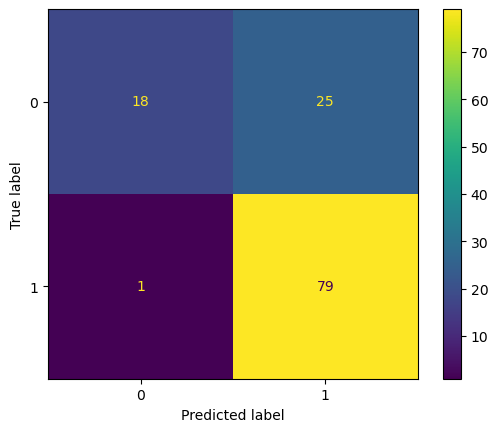

In [29]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [30]:
           Predicted
           No   Yes
Actual No   18    25
Actual Yes   1    79
The model performs well in identifying approved loans but still shows risk in false approvals, which can be improved using ensemble models like Random Forest.”

SyntaxError: invalid character '”' (U+201D) (2750648058.py, line 5)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
)

In [32]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred_rf)

0.7560975609756098

In [35]:
“I experimented with both Logistic Regression and Random Forest. Logistic Regression performed better on this dataset, showing that simpler models can outperform complex ones when data is limited and well-structured.”

SyntaxError: invalid character '“' (U+201C) (2244727882.py, line 1)

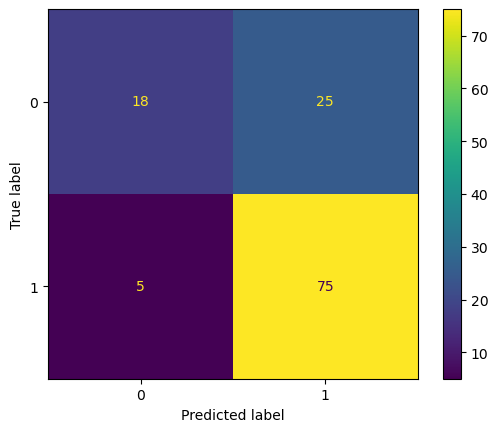

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test,y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()


In [38]:
import pandas as pd 

feature_importance = pd.Series(
       rf.feature_importances_,
       index=X.columns
).sort_values(ascending=False)

feature_importance

Credit_History       0.264849
ApplicantIncome      0.201967
LoanAmount           0.188281
CoapplicantIncome    0.108819
Loan_Amount_Term     0.051087
Property_Area        0.050538
Dependents           0.046962
Married              0.024777
Gender               0.021039
Self_Employed        0.020976
Education            0.020704
dtype: float64

In [ ]:
“Feature importance analysis showed that credit history was the most influential factor in loan approval, followed by applicant income and loan amount, aligning well with real-world banking decision processes.”